# 10 · CCA: daño diario, alertas y excedencias en Base frente a B

**Segundo punto:** separar banda por lectura, banda del máximo diario y cruces de 155 ppb. La banda por lectura está documentada en el experimento 09; aquí profundizamos en las decisiones diarias.

Se reutilizan **las mismas 100 campañas del 08**: 5 % de selección por lectura, N uniforme de 1 a 16 y posiciones 0…15. Se incluyen todos los intentos, sin restringir al grupo de aceptación común.

Predicciones y p95 **guardados de CCA del notebook 09 principal**, sin entrenamiento ni inferencia nueva. El umbral es 14.748355 ppb; el piloto de 22.6 ppb es otra referencia. No se modifica el detector ni se simula la propagación a entradas futuras.

## 1. Qué significa un día con daño

Cada campaña comienza con las mismas lecturas originales. Todos los ataques de una fecha se aplican juntos; calculamos el máximo de las lecturas disponibles **sólo de CCA**.

| Medida diaria | Condición |
|---|---|
| Cambio de banda | La banda del máximo recibido difiere de la del máximo original |
| Falsa excedencia | El máximo original es menor que 155 y el recibido alcanza o supera 155 ppb |
| Ocultamiento | El máximo original alcanza 155 y el recibido queda por debajo |

Un cruce del umbral experimental no equivale a activar o desactivar oficialmente una contingencia. Aquí sólo se evalúa el máximo observado de CCA.

Los rechazos dejan lecturas ausentes, nunca ceros. Si un día pierde todas sus lecturas, la decisión es indefinida y se cuenta aparte. Las alertas del LSTM se registran, **no eliminan automáticamente lecturas**.

La unidad de los conteos es **día-campaña**: 72 fechas × 100 sorteos = 7 200 por formato. No son 7 200 días independientes ni otros años de datos.

## 2. Una alerta en el día no demuestra detección del daño

Separamos tres observaciones:

1. **Hay daño diario:** cambió la banda o se produjo el cruce estudiado.
2. **Daño sin ninguna alerta del día:** ni las lecturas limpias ni las atacadas aceptadas generan alerta.
3. **Daño sin alerta en valores alterados:** ninguna lectura realmente modificada genera alerta; puede haber falsas alarmas en otras lecturas. Una cancelación que conserva el valor no se cuenta como alteración detectada.

La tercera tampoco equivale a identificar causalmente todo el ataque: puede haber daño por rechazo, y el LSTM no recibe esas lecturas. Un rechazo es visible al decodificador, pero no es una alerta del LSTM.

Por ejemplo: si un ataque baja 60 a 28 sin alerta y otra lectura limpia genera una falsa alarma, hubo una alerta en el día, pero esa alarma no demuestra que se detectara el ataque.

In [1]:
from pathlib import Path
import sys,importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
actual=Path.cwd().resolve()
RAIZ=next(p for p in (actual,*actual.parents) if (p/'experiments/cayenne_mod/diario_base_B.py').is_file())
if str(RAIZ) not in sys.path: sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import diario_base_B
diario_base_B=importlib.reload(diario_base_B)
r,info=diario_base_B.construir(RAIZ)
r2,info2=diario_base_B.construir(RAIZ)
assert info==info2
for nombre in r: pd.testing.assert_frame_equal(r[nombre],r2[nombre],check_exact=True)
del r2
info['reproducibilidad']='Dos ejecuciones idénticas del análisis diario; máximos, daños y alertas reproducen el 08'
DESTINO=diario_base_B.guardar(RAIZ,r,info)
print('Dos ejecuciones idénticas. Predicciones y p95 GUARDADOS; sin entrenamiento ni nueva inferencia.')
print(f"CCA: {info['n_mensajes']} lecturas, {info['n_dias']} días, {info['n_campanas']} campañas; p95 {info['umbral_ppb']:.6f} ppb.")
print('Máximos, daño diario y conteos de alertas coinciden con el experimento 08.')
print('Archivos:',DESTINO.relative_to(RAIZ))

Dos ejecuciones idénticas. Predicciones y p95 GUARDADOS; sin entrenamiento ni nueva inferencia.
CCA: 1684 lecturas, 72 días, 100 campañas; p95 14.748355 ppb.
Máximos, daño diario y conteos de alertas coinciden con el experimento 08.
Archivos: experiments/cayenne_mod/resultados/10


## 3. Comparación diaria principal

Todos los números son acumulados de las 100 campañas. «Sin alerta en alterados» incluye daños por pérdida: no presupone que existía una lectura válida para que el LSTM la detectara.

La diferencia entre las dos columnas de alertas evita atribuir éxito al detector por una alarma en otra lectura del mismo día.

In [2]:
s=r['resumen']
cols={'formato':'Formato','dias_danados':'Días-campaña con banda distinta',
      'media_por_campana':'Promedio por campaña','sin_alerta_alguna':'Sin ninguna alerta del día',
      'sin_alerta_en_alterados':'Sin alerta en valores alterados','dias_sin_datos':'Días sin datos'}
display(s.query("tipo == 'banda'")[list(cols)].rename(columns=cols).reset_index(drop=True))

,Formato,Días-campaña con banda distinta,Promedio por campaña,Sin ninguna alerta del día,Sin alerta en valores alterados,Días sin datos
0,base,133,1.33,5,32,0
1,B,366,3.66,5,29,0


## 4. Separar cambios de valor y pérdidas de lecturas

Usamos dos referencias explicativas:

- **Sólo valores:** mantenemos las alteraciones aceptadas y restauramos los originales de los rechazos.
- **Sólo pérdidas:** conservamos los rechazos y restauramos el original de cada lectura aceptada.

Si un día tenía daño real, lo clasificamos según si el daño también aparece en cada referencia. Puede aparecer en ambas por separado o requerir su interacción. Los conteos «sólo valores» y «sólo pérdidas» no son necesariamente sumables.

Ejemplo de interacción: originales 60, 59 y 20. Si se rechaza 60 y se cambia 59 a 27, el máximo queda en 27. Sólo perder 60 deja máximo 59; sólo cambiar 59 deja máximo 60. Ninguna acción por separado cambia la banda, pero juntas sí.

Estas referencias usan originales que el simulador conoce. **No son imputaciones que el receptor pueda realizar.**

In [3]:
display(r['fuentes_dano'].query("tipo == 'banda'").reset_index(drop=True))
print('Cada día dañado pertenece a una sola categoría de esta tabla.')
print('Sólo valores suficientes: el daño aparece con alteraciones aisladas, no con pérdidas aisladas; puede haber pérdidas en el día.')

,formato,tipo,fuente,dias_campana
0,base,banda,solo_valores_suficientes,104
1,base,banda,solo_perdidas_suficientes,29
2,B,banda,solo_valores_suficientes,339
3,B,banda,solo_perdidas_suficientes,25
4,B,banda,valores_y_perdidas_por_separado,1
5,B,banda,interaccion,1


Cada día dañado pertenece a una sola categoría de esta tabla.
Sólo valores suficientes: el daño aparece con alteraciones aisladas, no con pérdidas aisladas; puede haber pérdidas en el día.


## 5. Comprobar si las alertas cubren el daño observado

Hay días con una alerta sobre un valor alterado, pero esa lectura podría no ser la responsable de que el máximo cambie de banda. Por eso hacemos dos reconstrucciones diagnósticas adicionales:

| Reconstrucción | Qué hacemos | Qué pregunta responde |
|---|---|---|
| Restaurar alterados detectados | Reemplazamos por su original cada valor alterado que generó alerta; conservamos los rechazos | ¿El daño real persiste pese a corregir esas alteraciones? |
| Sólo alteraciones sin alerta | Además restauramos los rechazados; quedan únicamente alteraciones aceptadas sin alerta | ¿El daño real persiste sólo con esos cambios silenciosos? |

**No proponemos que el sistema conozca los valores originales ni que pueda corregirlos así.** Esto permite estudiar qué alteraciones sostienen el daño. No es una simulación de eliminación de mensajes ni una defensa desplegable.

Sólo contamos persistencia en días que ya tenían ese daño en la campaña real. Las columnas se solapan y no deben sumarse. Una reconstrucción sin daño no significa que el LSTM ya lo haya evitado: actualmente sólo alerta.

,Formato,Días con banda distinta,Persiste al restaurar detectados (con pérdidas),Persiste sólo con alteraciones sin alerta
0,base,133,33,4
1,B,366,31,5


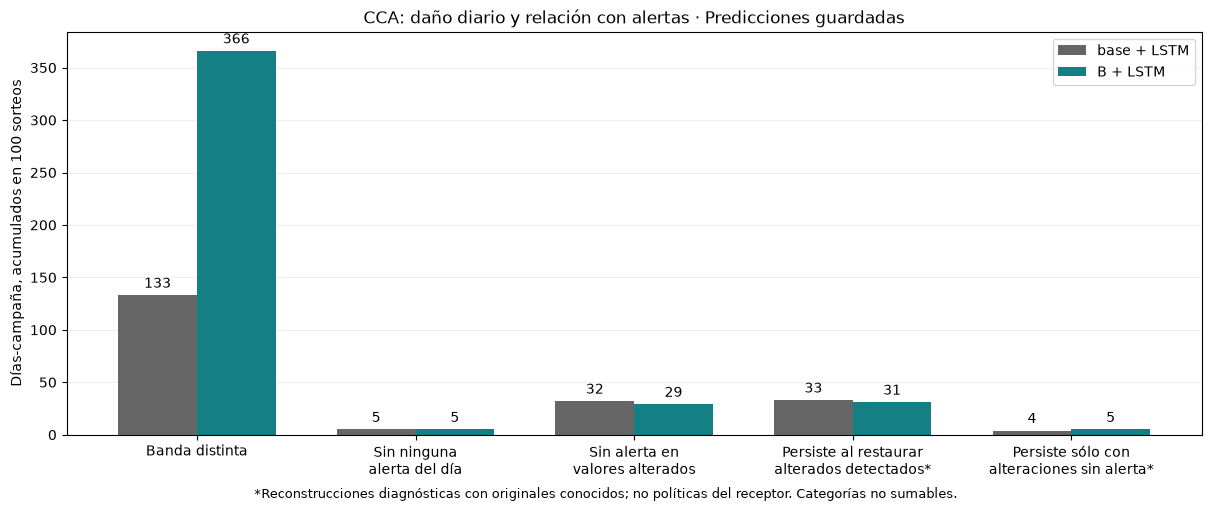

In [4]:
cols={'formato':'Formato','dias_danados':'Días con banda distinta',
      'persiste_restaurando_detectados':'Persiste al restaurar detectados (con pérdidas)',
      'persiste_solo_silenciosos':'Persiste sólo con alteraciones sin alerta'}
display(s.query("tipo == 'banda'")[list(cols)].rename(columns=cols).reset_index(drop=True))
diario_base_B.graficar(r,DESTINO)
plt.show()

## 6. Falsas excedencias y ocultamientos de 155 ppb

La comparación de falsas excedencias sí es evaluable en este periodo. **El ocultamiento no:** el máximo original de CCA es 145 ppb. Los ceros en ocultamiento expresan ausencia de casos originales, no protección perfecta.

Seguimos evaluando el máximo observado, no las condiciones completas para declarar una contingencia oficial.

In [5]:
cols={'formato':'Formato','dias_danados':'Días-campaña con falsa excedencia',
      'sin_alerta_alguna':'Sin ninguna alerta del día','sin_alerta_en_alterados':'Sin alerta en alterados',
      'persiste_solo_silenciosos':'Persiste sólo con alteraciones sin alerta'}
display(s.query("tipo == 'falsa_excedencia'")[list(cols)].rename(columns=cols).reset_index(drop=True))
print(f"Máximo original: {info['maximo_limpio_ppb']:.0f} ppb. Ocultamiento evaluable: {info['ocultamiento_evaluable']}.")
print('El informe conserva los conteos cero para auditoría; no calcula sensibilidad de ocultamiento sin casos positivos.')

,Formato,Días-campaña con falsa excedencia,Sin ninguna alerta del día,Sin alerta en alterados,Persiste sólo con alteraciones sin alerta
0,base,57,0,0,0
1,B,208,0,1,1


Máximo original: 145 ppb. Ocultamiento evaluable: False.
El informe conserva los conteos cero para auditoría; no calcula sensibilidad de ocultamiento sin casos positivos.


## 7. Ejemplos reales para inspeccionar

Se elige el primer caso de cada categoría y formato que exista. Pueden repetirse días entre categorías. Son ejemplos explicativos, no una muestra para estimar frecuencias.

Los máximos reconstruidos utilizan originales sólo para el diagnóstico. NA en un máximo recibido indicaría que ese día no quedaron datos, aunque no ocurrió en estas campañas.

In [6]:
cols=['ejemplo','semilla','formato','fecha','ataques','rechazos','maximo_original','maximo_recibido',
      'alertas_totales','alertas_alterados','maximo_restaurando_detectados','maximo_solo_silenciosos']
display(r['ejemplos'][cols].reset_index(drop=True))

,ejemplo,semilla,formato,fecha,ataques,rechazos,maximo_original,maximo_recibido,alertas_totales,alertas_alterados,maximo_restaurando_detectados,maximo_solo_silenciosos
0,Daño sin alerta en valores alterados,43,base,2025-12-05,2,2,91.0,87.0,4,0,87.0,91.0
1,Daño sin alerta en valores alterados,43,B,2025-12-05,2,2,91.0,87.0,4,0,87.0,91.0
2,Daño persiste al restaurar detectados,43,base,2025-12-05,2,2,91.0,87.0,4,0,87.0,91.0
3,Daño persiste al restaurar detectados,43,B,2025-12-05,2,2,91.0,87.0,4,0,87.0,91.0
4,Daño persiste sólo con alteraciones silenciosas,58,base,2025-11-10,1,0,41.0,68.0,12,0,68.0,68.0
5,Daño persiste sólo con alteraciones silenciosas,52,B,2025-11-19,2,1,84.0,92.0,4,0,92.0,92.0
6,Falsa excedencia sin alerta en alterados,81,B,2025-11-07,3,2,145.0,155.0,4,0,155.0,155.0


## 8. Qué podemos concluir de este segundo punto

- El máximo diario cambia de banda en **133 días-campaña de Base y 366 de B**, sobre 7 200 por formato. No son todos escapes: incluyen daño asociado a lecturas detectadas, que no se retiran automáticamente.
- Si sólo miráramos ausencia de cualquier alerta del día, veríamos **5 frente a 5**. Ese criterio mezcla señales de ataques con falsas alarmas en otras lecturas.
- El daño ocurre sin alerta en valores alterados en **32 días-campaña de Base y 29 de B**. Esta medida incluye pérdidas por rechazo; no prueba por sí sola mayor protección de B.
- Tras restaurar los valores alterados detectados, el daño persiste en **33 y 31** días-campaña. Si también restauramos rechazados, queda en **4 y 5**, respectivamente. Son diagnósticos del simulador, no eficacia de una política operativa.
- Hay **57 falsas excedencias diarias en Base y 208 en B**. Ninguna de Base y una de B ocurren sin alerta en valores alterados. La de B tiene alguna alerta en otra lectura del día: no podemos atribuirle detección del ataque.
- No hay evidencia para concluir una mejora global de B con estas campañas. Sus costos y beneficios cambian según la medida; las diferencias pequeñas de casos silenciosos no justifican superioridad estadística.

Se completa el análisis diario de CCA bajo el protocolo actual. El siguiente punto requiere un conjunto con excedencias originales ≥155 para evaluar ocultamiento con el detector, respetando el corte temporal. La validación en otras estaciones y años sigue pendiente. No reentrenamos ni cambiamos el umbral en este paso.

[Resumen para la junta](avance_junta_10.md).